<a href="https://colab.research.google.com/github/nirajkulkarni3605/ML_II/blob/main/bagging_boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Random dataset created successfully!
Number of samples: 1000
Number of features: 10

First 5 records:
   Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  Feature_6  \
0  -1.030931   1.391626   0.547274   0.928932  -1.738880   1.250002   
1  -2.766254   1.247870  -0.303691   1.083145   0.710836   1.968202   
2  -0.558987   0.299849   1.527071   0.360442  -1.360209   1.100793   
3  -1.350289  -2.046078  -0.614264   0.126459  -0.783923   5.895026   
4  -0.275754  -0.728495   0.027727  -0.660834  -1.928161   3.544945   

   Feature_7  Feature_8  Feature_9  Feature_10  Target  
0   1.332551   1.578256   2.124722   -0.318434       0  
1  -1.794192   2.346422   1.700778   -0.001190       1  
2  -0.755951   1.331933   2.041105   -0.824404       0  
3  -0.915477  -3.184768  -0.399260   -3.920960       0  
4   1.446944  -1.111662   0.313766   -2.376528       0  

Class distribution:
Target
1    502
0    498
Name: count, dtype: int64

Training data: (800, 10)
Testing data : (200, 10)

Baggi

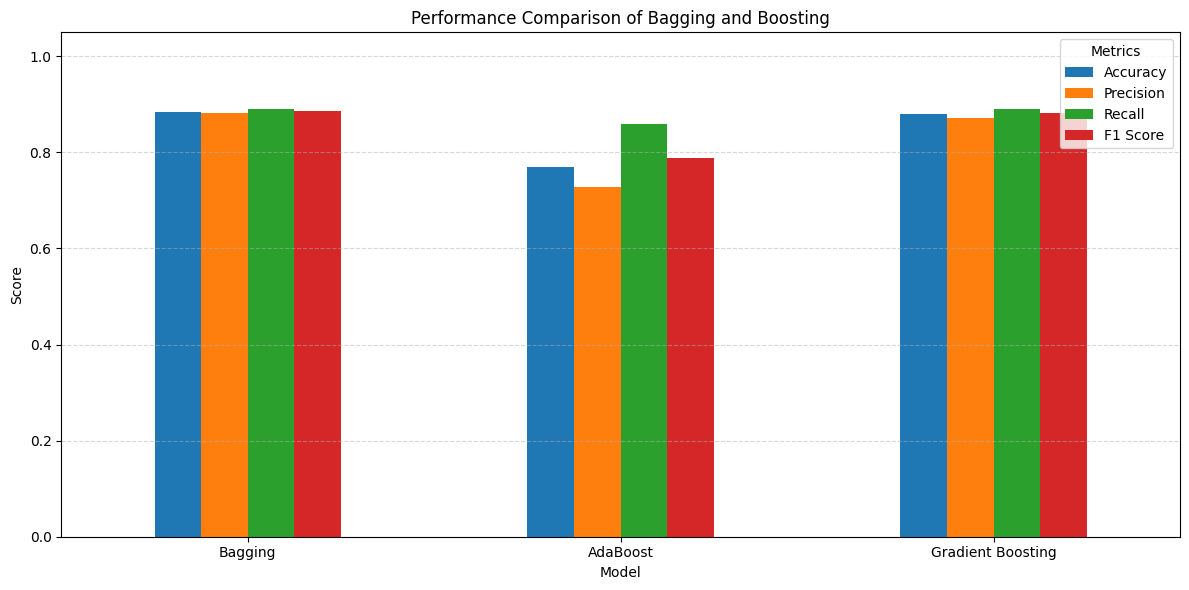

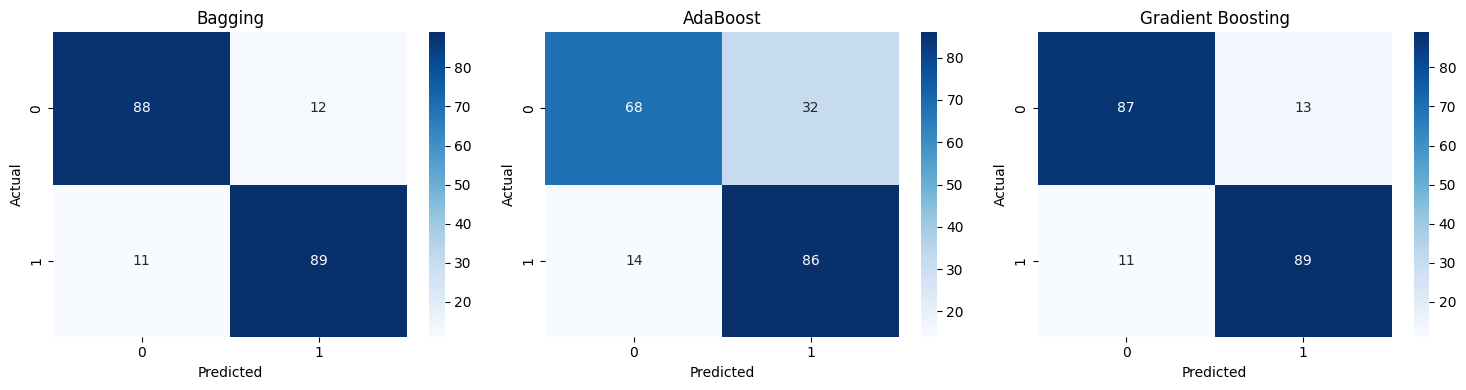


FINAL COMPARISON
           Bagging  AdaBoost  Gradient Boosting
Accuracy    0.8850    0.7700             0.8800
Precision   0.8812    0.7288             0.8725
Recall      0.8900    0.8600             0.8900
F1 Score    0.8856    0.7890             0.8812

Experiment completed successfully!


In [3]:
# ============================================================
# BAGGING AND BOOSTING CLASSIFICATION
# Random Dataset - No CSV Required
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# 1. CREATE RANDOM SUPERVISED DATASET
# ============================================================

X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_classes=2,
    random_state=42
)

print("Random dataset created successfully!")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])


# Convert to DataFrame
feature_names = [
    "Feature_1", "Feature_2", "Feature_3", "Feature_4",
    "Feature_5", "Feature_6", "Feature_7", "Feature_8",
    "Feature_9", "Feature_10"
]

df = pd.DataFrame(X, columns=feature_names)
df["Target"] = y

print("\nFirst 5 records:")
print(df.head())

print("\nClass distribution:")
print(df["Target"].value_counts())


# ============================================================
# 2. SEPARATE INPUT AND OUTPUT
# ============================================================

X = df.drop("Target", axis=1)
y = df["Target"]


# ============================================================
# 3. SPLIT DATA INTO TRAINING AND TESTING
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data:", X_train.shape)
print("Testing data :", X_test.shape)


# ============================================================
# 4. BAGGING MODEL
# ============================================================

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)


# ============================================================
# 5. BOOSTING MODELS
# ============================================================

adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=1,
        random_state=42
    ),
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

gradient_boosting = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)


# ============================================================
# 6. STORE MODELS
# ============================================================

models = {
    "Bagging": bagging,
    "AdaBoost": adaboost,
    "Gradient Boosting": gradient_boosting
}


# ============================================================
# 7. TRAIN AND TEST MODELS
# ============================================================

results = {}

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store results
    results[name] = [
        accuracy,
        precision,
        recall,
        f1
    ]

    # Print results
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print("\nAccuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    print("Confusion Matrix:")
    print(
        confusion_matrix(
            y_test,
            y_pred
        )
    )


# ============================================================
# 8. CREATE COMPARISON TABLE
# ============================================================

results_df = pd.DataFrame(
    results,
    index=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

print("\n" + "=" * 60)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)

print(
    results_df.round(4)
)


# ============================================================
# 9. PLOT PERFORMANCE COMPARISON
# ============================================================

results_df.T.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Performance Comparison of Bagging and Boosting"
)

plt.xlabel("Model")
plt.ylabel("Score")

plt.ylim(0, 1.05)

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.legend(
    title="Metrics"
)

plt.tight_layout()
plt.show()


# ============================================================
# 10. CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

for ax, (name, model) in zip(
    axes,
    models.items()
):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


# ============================================================
# 11. FINAL COMPARISON
# ============================================================

print("\n" + "=" * 60)
print("FINAL COMPARISON")
print("=" * 60)

print(results_df.round(4))

print("\nExperiment completed successfully!")
